# 02 — XGBoost Login Form Detector

Trains an XGBoost binary classifier to detect malicious login forms.

**Features:** exclusive 6-gram tag-sequence flags + match count.

**No leakage:** the raw training rows are split *first*; the qualifying sequences are
then mined on the **train split only** and applied unchanged to the test and retest
sets.

- **Train:** `train_login_form-2026-08.csv` + `train_no_form-2026-08.csv` (deduplicated)
- **Retest:** `signed_retest_login_form.csv` + `signed_retest_no_form.csv` (held-out, unseen)

## 1. Load & Clean Data

In [1]:
import json
import re
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from collections import Counter
import mlflow
import mlflow.xgboost
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, precision_recall_fscore_support, accuracy_score
)

RANDOM_STATE = 42
NGRAM_N = 6

import sys
sys.path.insert(0, '../../src')
from features import (CREDENTIAL_GROUP, tokenize, get_ngrams, count_ngrams,
                      has_cred_tag, mine_sequences, build_features)

lf = pd.read_csv("../../data/train/train_login_form-2026-08.csv", sep=";")
nf = pd.read_csv("../../data/train/train_no_form-2026-08.csv", index_col=0)
if "schreenshot_path" in nf.columns:
    nf.drop(columns=["schreenshot_path"], inplace=True)
lf.dropna(subset=["html_signature"], inplace=True)
nf.dropna(subset=["html_signature"], inplace=True)

df = pd.concat([lf, nf], ignore_index=True)
df = df.drop_duplicates(subset=["html_signature"]).reset_index(drop=True)
df["binary_label"] = (df["label"] == "LOGIN_FORM_MALICIOUS").astype(int)

print(f"Train rows (deduplicated): {len(df)} | Malicious: {df['binary_label'].sum()} | No-Form: {(df['binary_label']==0).sum()}")

Train rows (deduplicated): 2072 | Malicious: 878 | No-Form: 1194


In [2]:
from pathlib import Path
_DB = Path("../../mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{_DB}")
if mlflow.active_run():
    mlflow.end_run()
mlflow.set_experiment("login-form-detection")
_active_run = mlflow.start_run(run_name="sequence-xgboost")
print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"MLflow run   : {_active_run.info.run_id[:8]}")

Tracking URI : sqlite:////Users/nelson.mutua/Desktop/ThreatLabz/Login_Forms_Detection/mlflow.db
MLflow run   : f24ab970


## 2. Split Rows First, Then Mine Sequences on Train Only

To avoid leakage, the raw rows are split **before** any feature selection. The qualifying
6-gram sequences are mined on the **train split only** and then applied unchanged to build the
train / test (and later retest) feature matrices — the test set never influences which sequences
are selected.

In [3]:
# Split raw rows before any feature computation — ensures no leakage into sequence mining
df_train, df_test = train_test_split(
    df, test_size=0.2, stratify=df["binary_label"], random_state=RANDOM_STATE
)

print(f"Train : {len(df_train)} rows | Malicious: {df_train['binary_label'].sum()} | No-Form: {(df_train['binary_label']==0).sum()}")
print(f"Test  : {len(df_test)} rows  | Malicious: {df_test['binary_label'].sum()} | No-Form: {(df_test['binary_label']==0).sum()}")

Train : 1657 rows | Malicious: 702 | No-Form: 955
Test  : 415 rows  | Malicious: 176 | No-Form: 239


In [4]:
# Mine qualifying sequences on the TRAIN split ONLY, then build feature matrices
mal_sigs = df_train[df_train["binary_label"] == 1]["html_signature"]
nf_sigs  = df_train[df_train["binary_label"] == 0]["html_signature"]
QUALIFYING_SEQS = mine_sequences(mal_sigs, nf_sigs, NGRAM_N)
SEQ_COLS      = ["seq_" + ng.replace(" > ", "__") for ng in QUALIFYING_SEQS]
FEATURE_NAMES = SEQ_COLS + ["seq_match_count"]

X_train = build_features(df_train["html_signature"], QUALIFYING_SEQS, NGRAM_N)
X_test  = build_features(df_test["html_signature"],  QUALIFYING_SEQS, NGRAM_N)
y_train = df_train["binary_label"].values
y_test  = df_test["binary_label"].values

print(f"Qualifying {NGRAM_N}-gram sequences (train-mined): {len(QUALIFYING_SEQS)}")
print(f"Feature columns : {len(FEATURE_NAMES)} ({len(SEQ_COLS)} seq flags + 1 match-count)")
print(f"\nQualifying {NGRAM_N}-grams:")
for i, seq in enumerate(sorted(QUALIFYING_SEQS), 1):
    print(f"  {i:2d}. {seq}")

Qualifying 6-gram sequences (train-mined): 17
Feature columns : 18 (17 seq flags + 1 match-count)

Qualifying 6-grams:
   1. a > span > iframe > div > div > div
   2. div > div > div > style > script > script
   3. div > div > input > div > input > input
   4. div > div > style > script > script > div
   5. div > form > div > ul > div > div
   6. div > input > div > div > div > label
   7. input > a > span > iframe > div > div
   8. input > div > div > div > label > span
   9. input > div > div > input > div > input
  10. input > input > a > span > iframe > div
  11. input > input > input > a > span > iframe
  12. input > input > input > input > a > span
  13. input > input > input > input > input > a
  14. label > span > div > div > label > span
  15. label > span > div > input > div > div
  16. span > div > div > label > span > div
  17. span > div > input > div > div > input


## 3. Train XGBoost

In [5]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 4. Evaluation


Train Set


,Precision,Recall,F1-Score,Support
Class,,,,
NO_FORM,64.6%,99.6%,78.3%,955
LOGIN_FORM_MALICIOUS,97.8%,25.6%,40.6%,702
Accuracy,,,68.3%,1657
ROC-AUC,,,63.4%,



Test Set


,Precision,Recall,F1-Score,Support
Class,,,,
NO_FORM,65.3%,100.0%,79.0%,239
LOGIN_FORM_MALICIOUS,100.0%,27.8%,43.6%,176
Accuracy,,,69.4%,415
ROC-AUC,,,64.5%,


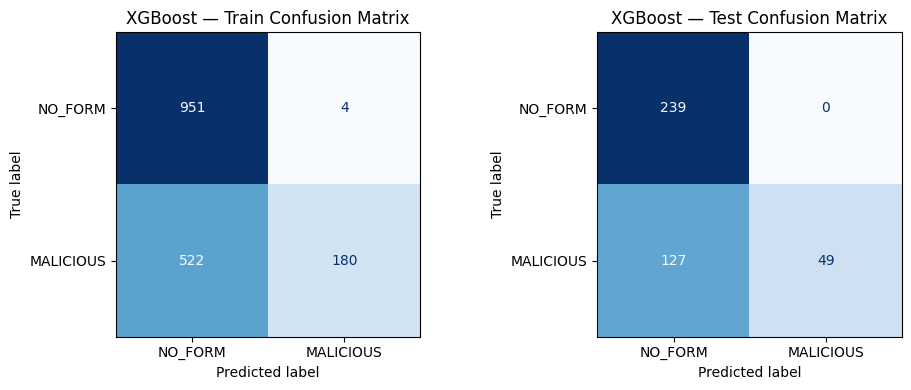

In [6]:
classes = ["NO_FORM", "LOGIN_FORM_MALICIOUS"]

def report_table(y_true, y_pred, y_prob, label):
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    rows = []
    for i, cls in enumerate(classes):
        rows.append({"Class": cls, "Precision": f"{prec[i]*100:.1f}%",
                     "Recall": f"{rec[i]*100:.1f}%", "F1-Score": f"{f1[i]*100:.1f}%",
                     "Support": int(sup[i])})
    rows.append({"Class": "Accuracy", "Precision": "", "Recall": "",
                 "F1-Score": f"{acc*100:.1f}%", "Support": int(sup.sum())})
    rows.append({"Class": "ROC-AUC", "Precision": "", "Recall": "",
                 "F1-Score": f"{auc*100:.1f}%", "Support": ""})
    print(f"\n{label}")
    display(pd.DataFrame(rows).set_index("Class"))
    return acc, auc

y_train_pred = model.predict(X_train)
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_pred  = model.predict(X_test)
y_test_prob  = model.predict_proba(X_test)[:, 1]

train_acc, train_auc = report_table(y_train, y_train_pred, y_train_prob, "Train Set")
test_acc,  test_auc  = report_table(y_test,  y_test_pred,  y_test_prob,  "Test Set")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_t, y_p, title in [
    (axes[0], y_train, y_train_pred, "Train"),
    (axes[1], y_test,  y_test_pred,  "Test"),
]:
    cm = confusion_matrix(y_t, y_p)
    ConfusionMatrixDisplay(cm, display_labels=["NO_FORM", "MALICIOUS"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"XGBoost — {title} Confusion Matrix")
plt.tight_layout()
plt.show()

## 5. Retest on Unseen Data

In [7]:
lf_rt = pd.read_csv("../../data/retest/signed_retest_login_form.csv", index_col=0)
nf_rt = pd.read_csv("../../data/retest/signed_retest_no_form.csv", index_col=0)

for df_ in [lf_rt, nf_rt]:
    for junk in ("Unnamed: 0", "schreenshot_path"):
        if junk in df_.columns:
            df_.drop(columns=[junk], inplace=True)

df_rt = pd.concat([lf_rt, nf_rt], ignore_index=True)
df_rt.dropna(subset=["html_signature"], inplace=True)
df_rt.reset_index(drop=True, inplace=True)

# derive label from the `label` column (TEST_LOGIN_FORM -> 1), not file of origin
df_rt["binary_label"] = df_rt["label"].str.contains("LOGIN_FORM", case=False, na=False).astype(int)

print(f"Retest dataset : {len(df_rt)} rows | Malicious: {df_rt['binary_label'].sum()} | No-Form: {(df_rt['binary_label']==0).sum()}")

Retest dataset : 208 rows | Malicious: 109 | No-Form: 99


In [8]:
# build retest features using the SAME train-mined sequences
X_rt = build_features(df_rt["html_signature"], QUALIFYING_SEQS, NGRAM_N)
y_rt = df_rt["binary_label"].values

print(f"Retest feature matrix : {X_rt.shape}")

Retest feature matrix : (208, 18)


In [9]:
y_rt_pred = model.predict(X_rt)
y_rt_prob = model.predict_proba(X_rt)[:, 1]

classes = ["NO_FORM", "LOGIN_FORM_MALICIOUS"]
prec, rec, f1, sup = precision_recall_fscore_support(y_rt, y_rt_pred)
acc = accuracy_score(y_rt, y_rt_pred)
auc = roc_auc_score(y_rt, y_rt_prob)

rows = []
for i, cls in enumerate(classes):
    rows.append({
        "Class":     cls,
        "Precision": f"{prec[i]*100:.1f}%",
        "Recall":    f"{rec[i]*100:.1f}%",
        "F1-Score":  f"{f1[i]*100:.1f}%",
        "Support":   int(sup[i]),
    })
rows.append({"Class": "Accuracy", "Precision": "", "Recall": "", "F1-Score": f"{acc*100:.1f}%", "Support": int(sup.sum())})
rows.append({"Class": "ROC-AUC",  "Precision": "", "Recall": "", "F1-Score": f"{auc*100:.1f}%", "Support": ""})

print("Retest Classification Report")
display(pd.DataFrame(rows).set_index("Class"))

Retest Classification Report


,Precision,Recall,F1-Score,Support
Class,,,,
NO_FORM,61.6%,99.0%,76.0%,99
LOGIN_FORM_MALICIOUS,98.0%,44.0%,60.8%,109
Accuracy,,,70.2%,208
ROC-AUC,,,72.2%,


In [10]:
mlflow.log_metrics({
    "train_accuracy":       train_acc,
    "test_accuracy":        test_acc,
    "retest_accuracy":      acc,
    "train_roc_auc":        train_auc,
    "test_roc_auc":         test_auc,
    "retest_roc_auc":       auc,
    "retest_mal_precision": float(prec[1]),
    "retest_mal_recall":    float(rec[1]),
    "retest_mal_f1":        float(f1[1]),
})
print("Metrics logged to MLflow.")

Metrics logged to MLflow.


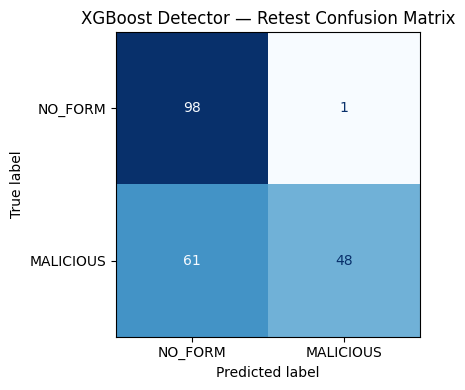


False Positives : 1  (NO_FORM flagged as malicious)
False Negatives : 61  (malicious pages missed)

--- False Positives (sample) ---


,url,html_signature
200,https://xfinitycomcastalert.weebly.com,(body(div(div(div(div(span)))(div(span(a(img))...



--- False Negatives (sample) ---


,url,html_signature
0,http://bitcb-tlforms.net/login.php,(body(div(div)(img)(div)(div(img))(div(div(div...
4,http://currentfromatt.wixsite.com/my-site-1,(body(script)(script)(script)(script)(div(div(...
5,http://hsbc-gateway-demo-broker.azurewebsites.net,(body(div(div(div(div(div)(div)(div(div)(butto...
6,http://instagrambeta.github.io,(body(div(style)(img)(span(img)))(div(div(div(...
7,http://instagram-com-post-n97stav.vercel.app,(body(main(div(div(img)(div(form(input)(input)...
8,http://instagramhelp.azurewebsites.net/instagram,(body(form(div(input)(input)(input))(script)(s...
9,http://installment-payu-ios.maklifedairy.in,(body(div(header(div(div(img))(div(ul(li(a(img...
11,http://lesmmsvocaleorange.godaddysites.com,(body(div(div(div(div(div(div(div)(section(div...
13,http://pagina.pro/help-facebook-support-authen...,(body(div(div)(div(div(div)(div(form(input)(in...
14,http://payment.smbstaging.enterprisedeliveries...,(body(header(div(div(a(img)))(div(div(div(butt...


In [11]:
cm_rt = confusion_matrix(y_rt, y_rt_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rt, display_labels=["NO_FORM", "MALICIOUS"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("XGBoost Detector — Retest Confusion Matrix")
plt.tight_layout()
plt.show()

fp_rt = df_rt[(y_rt_pred == 1) & (y_rt == 0)]
fn_rt = df_rt[(y_rt_pred == 0) & (y_rt == 1)]

print(f"\nFalse Positives : {len(fp_rt)}  (NO_FORM flagged as malicious)")
print(f"False Negatives : {len(fn_rt)}  (malicious pages missed)")

if len(fp_rt):
    print("\n--- False Positives (sample) ---")
    display(fp_rt[["url", "html_signature"]].head(10))

if len(fn_rt):
    print("\n--- False Negatives (sample) ---")
    display(fn_rt[["url", "html_signature"]].head(10))

## 6. Save Model

In [12]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../../models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(model, MODELS_DIR / "sequence_xgboost.pkl")
with open(MODELS_DIR / "sequence_qualifying_seqs.json", "w") as f:
    json.dump(QUALIFYING_SEQS, f, indent=2)

mlflow.log_params({
    "n_estimators":      model.n_estimators,
    "max_depth":         model.max_depth,
    "learning_rate":     model.learning_rate,
    "subsample":         model.subsample,
    "colsample_bytree":  model.colsample_bytree,
    "feature_track":     "sequence_6gram",
    "ngram_n":           NGRAM_N,
    "n_qualifying_seqs": len(QUALIFYING_SEQS),
    "random_state":      RANDOM_STATE,
})
mlflow.xgboost.log_model(model, "model")
mlflow.log_artifact(str(MODELS_DIR / "sequence_qualifying_seqs.json"))
mlflow.end_run()

print(f"Saved → models/sequence_xgboost.pkl")
print(f"Saved → models/sequence_qualifying_seqs.json  ({len(QUALIFYING_SEQS)} sequences)")
print("MLflow run complete.")

2026/09/07 10:47:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Saved → models/sequence_xgboost.pkl
Saved → models/sequence_qualifying_seqs.json  (17 sequences)
MLflow run complete.
